# 01 · Who should we email? — customer-level uplift  ⭐ ANCHOR A

**The business decision.** We have a €10 discount and a customer list. Emailing *everyone*
burns margin on people who would have bought anyway, and a discount email can even annoy some
loyal customers into unsubscribing. Emailing *no one* leaves money on the table. So the
question is not "does the email work on average?" but **"for which individual customers does
sending the email actually change what they do?"**

### The one idea this whole notebook rests on

For each customer there are two possible futures: the spend we'd see **if we email them**, and
the spend we'd see **if we don't**. Statisticians call these two futures *potential outcomes*
and write them $Y(1)$ (emailed) and $Y(0)$ (not emailed). The thing we care about is the
**difference** — how much the email *changes* that customer's spend:

$$\tau_i \;=\; Y_i(1) - Y_i(0). \qquad \text{(the customer's individual treatment effect, in €)}$$

We use the Greek letter **τ ("tau")** for this effect throughout. When it depends on the
customer's characteristics $x$ (recency, engagement, …) we write it as a function $\tau(x)$.

The catch — the **"fundamental problem of causal inference"** — is that for any one customer we
only ever get to see *one* of the two futures: we either emailed them or we didn't, never both.
So $\tau_i$ is never directly observed for anybody. Everything that follows is a disciplined way
of *filling in the future we didn't see*.

### Four kinds of customer — and why only the effect tells them apart

Sort customers by what they do in each of the two futures, and four types appear. Notice that
two customers can have the *same observed behaviour* ("bought after being emailed") yet be
completely different types:

| | **buys if emailed** | **doesn't buy if emailed** |
|---|---|---|
| **buys if not emailed** | 🟡 *Sure Thing* — would buy anyway, so τ ≈ 0 (the discount is pure waste) | 🔴 *Sleeping Dog* — the email **backfires**, τ < 0 (reminding them prompts an unsubscribe/return) |
| **doesn't buy if not emailed** | 🟢 *Persuadable* — the email *tips them over*, τ > 0 (**the only type worth paying to reach**) | ⚪ *Lost Cause* — won't buy regardless, τ ≈ 0 |

Only the **Persuadables** are worth a discount. But you cannot identify them from who bought —
a Sure Thing and a Persuadable both "bought after the email." You can only separate them by
estimating the *effect* τ, which is why plain response models (predicting who buys) are the
wrong tool and **uplift models** (predicting whose behaviour *changes*) are the right one.

Targeting is worthwhile **only because τ varies across customers** ("heterogeneity"). If every
customer had the same τ, there'd be nothing to select on — you'd rationally email everyone (if
τ > cost) or no one (if τ < cost). So the entire problem reduces to: **estimate the per-customer
effect $\tau(x)$ well, then turn it into a euro decision that respects how unsure we are.**

### How this notebook is organised

It follows the repo's fixed **7-step contract**, then adds **three depths** a data scientist
needs to defend the number to a skeptic:

- **Steps** — 1 question · 2 simulate a known truth · 3 identify · 4 estimate · 5 validate ·
  6 decide in € · 7 caveats
- **Depth A** estimator bake-off & failure modes · **Depth B** identification rigour & sensitivity ·
  **Depth C** euro policy, value-of-information & test design

> **A note on "Bayesian."** We fit models that return not a single number but a *distribution* of
> plausible values for each effect — a **posterior**. In the narration we never dwell on the
> machinery; a posterior just lets us say *"how sure are we, and does that change what we'd do?"*
> A **90% credible interval** below means "given the data and model, there's a 90% chance the true
> value lies in this range."


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# cmp is this repo's shared package (src/cmp): dgp = data simulators,
# estimators = the models, metrics = validation, policy = the euro decision, plots = styling.
from cmp import dgp, estimators as est, metrics, policy, plots
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"   # FAST=1: quick, coarse posteriors (CI/live reruns)
SEED = 7
COST = 8.0                       # € cost of one discount contact (the number a target must beat)
N    = 900 if FAST else 1600
PROF = dict(draws=140, tune=140, chains=2, m=30) if FAST else dict(draws=600, tune=600, chains=4, m=100)
rng  = np.random.default_rng(SEED)
print(f"FAST={FAST}  N={N}  sampling={PROF}")

FAST=False  N=1600  sampling={'draws': 600, 'tune': 600, 'chains': 4, 'm': 100}


## 2 · Simulate a ground truth (why we start with fake data)

Here is the uncomfortable fact that shapes how we *validate* any causal method: **on real data
we can never check whether the method got the effect right**, because the true effect $\tau_i$ is
never observed for anyone (we only saw one of their two futures). If we just ran a fancy model on
real data and it printed "€6.10", we'd have no way to know if that's right or nonsense.

The way out — used in every notebook here — is **validation-first**: we build a *simulator* that
plants a **known** effect for each customer, generate data from it, and then see whether the
method **recovers the number we planted**. Only after a method passes that test on data where we
know the answer do we trust it on data where we don't. (Section 6b then runs the same pipeline on a
real public dataset, where we can no longer grade recovery but can still make the decision.)

**What the simulator plants.** Each customer gets:

- five features $x$ — `recency` (days since last purchase), `frequency`, `monetary`, `tenure`,
  `engage` (an engagement score);
- a true per-customer effect $\tau(x)$ (in €), deliberately *heterogeneous* — engaged, mid-recency
  customers are **Persuadables** (large positive τ); habitual high-frequency but low-engagement
  customers are **Sleeping Dogs** (τ < 0, the email nudges them to unsubscribe); the rest sit near 0;
- a **selection rule** that decides who got emailed in the past. In the *observational* world we use
  here, marketers historically emailed the already-engaged, recently-active customers — so whether a
  customer was emailed is **tangled up with the kind of customer they are**. That tangling is called
  **confounding**, and it is exactly what makes the naive answer wrong (Step 4 and Depth A show it).


In [2]:
df = dgp.uplift_customers(n=N, regime="observational", confounder_strength=0.0, cost=COST, seed=SEED)
feat = df.attrs["feature_cols"]          # the five feature column names
X, T, y, tau = df[feat].values, df["T"].values, df["y"].values, df["tau"].values
# T = 1 if emailed else 0 ; y = observed spend (€) ; tau = the PLANTED true effect (known only in sim)

# classify the four uplift types from the known truth (for teaching only — unknown in practice)
types = np.where(tau > COST, "persuadable",
         np.where(tau < 0, "sleeping dog", "sure thing / lost cause"))
print(f"True ATE (average of tau over everyone) = €{tau.mean():.2f}")
print(f"Share historically emailed              = {T.mean():.0%}")
print("\nShare of each uplift type in the base:")
print(pd.Series(types).value_counts(normalize=True).round(2).to_string())
df[feat + ['T','y','tau']].head()

True ATE (average of tau over everyone) = €5.95
Share historically emailed              = 48%

Share of each uplift type in the base:
sure thing / lost cause    0.4
sleeping dog               0.3
persuadable                0.3


,recency,frequency,monetary,tenure,engage,T,y,tau
0,208.156027,4.0,84.060202,44.320568,0.545720,1.0,45.878520,5.658414
1,296.594485,3.0,48.303531,32.765013,0.518337,1.0,32.005618,-0.008397
2,257.097849,5.0,46.447918,51.242745,0.921777,0.0,45.778013,0.785915
3,78.192337,9.0,90.968991,39.685558,0.411379,0.0,48.419005,18.905056
4,102.554043,4.0,44.561913,11.017535,0.447583,1.0,59.161710,23.398746


The three panels below are the picture to hold in your head for the rest of the notebook:

1. **The planted effect is spread out** (not a single value) — that spread is the *heterogeneity*
   that makes targeting possible, and it straddles both 0 and the €8 cost line.
2. **Persuadables cluster in feature space** — high τ (green) lives at particular recency/engagement
   combinations, which is *why* a model using $x$ can find them.
3. **The confounding, made visible** — the probability of having been emailed *rises with
   engagement*. Emailed and not-emailed customers are therefore **not comparable as-is**; that is the
   problem every method below has to overcome.


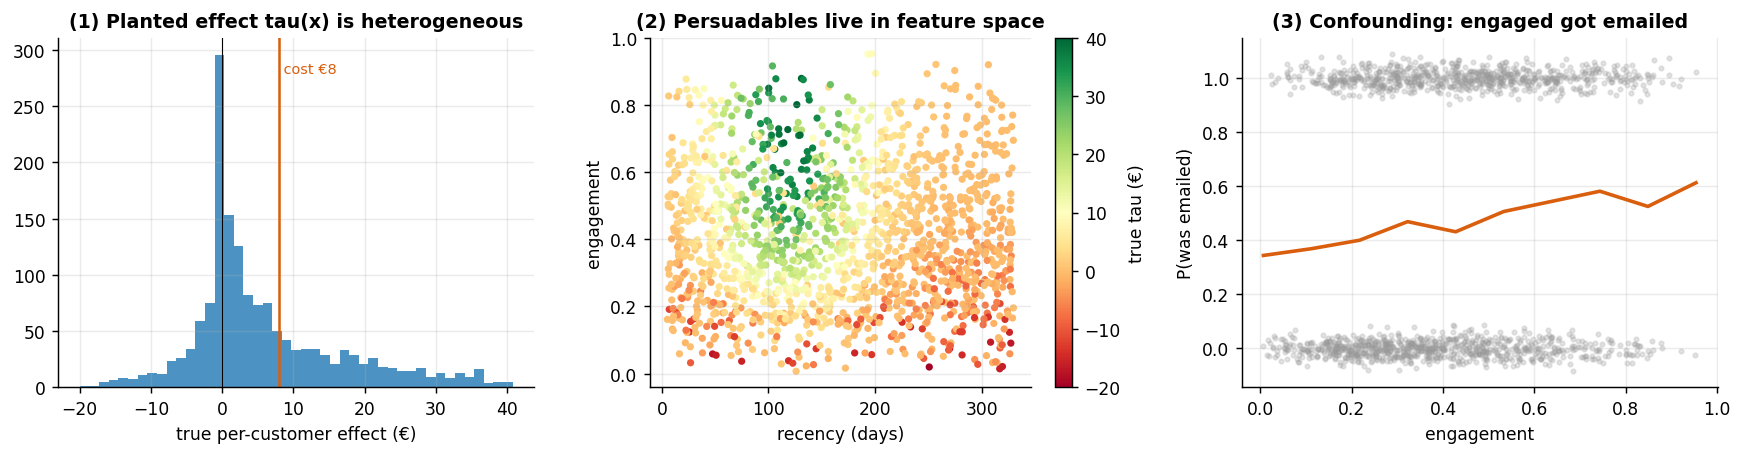

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
ax[0].hist(tau, bins=45, color=plots.BLUE, alpha=0.85)
ax[0].axvline(COST, color=plots.ORANGE, lw=1.4); ax[0].axvline(0, color="k", lw=0.6)
ax[0].text(COST, ax[0].get_ylim()[1]*0.9, f" cost €{COST:.0f}", fontsize=8, color=plots.ORANGE)
ax[0].set_title("(1) Planted effect tau(x) is heterogeneous"); ax[0].set_xlabel("true per-customer effect (€)")
sc = ax[1].scatter(df.recency, df.engage, c=tau, cmap="RdYlGn", s=9, vmin=-20, vmax=40)
ax[1].set_xlabel("recency (days)"); ax[1].set_ylabel("engagement"); ax[1].set_title("(2) Persuadables live in feature space")
plt.colorbar(sc, ax=ax[1], label="true tau (€)")
ax[2].scatter(df.engage, df["T"] + rng.normal(0, 0.03, N), s=6, alpha=0.25, color=plots.GREY)
rate = df.groupby(pd.qcut(df.engage, 10), observed=True)["T"].mean()
ax[2].plot(np.linspace(df.engage.min(), df.engage.max(), 10), rate.values, color=plots.ORANGE, lw=2)
ax[2].set_xlabel("engagement"); ax[2].set_ylabel("P(was emailed)"); ax[2].set_title("(3) Confounding: engaged got emailed")
fig.tight_layout()

## 3 · Identify — what exactly are we estimating, and when is it even possible?

**"Identification" vs "estimation" — the single most important distinction in causal inference.**
*Identification* asks: *given how the world works, can the effect in principle be recovered from
this data at all?* That is a question about **assumptions**, answered before you fit anything.
*Estimation* is the statistics you do *once identification is granted*. A beautiful model computed
under a false identification assumption is **confidently wrong** — so we keep the two separate.

**The estimand (the precise thing we want).** We climb a ladder of three related quantities:

| quantity | plain meaning | formula |
|---|---|---|
| **ATE** — Average Treatment Effect | "does emailing lift spend *overall*?" | $\mathbb{E}[Y(1)-Y(0)]$ |
| **CATE** — Conditional ATE, $\tau(x)$ | "the effect *for customers like $x$*" → *who* to target | $\mathbb{E}[Y(1)-Y(0)\mid X=x]$ |
| **policy value** | "the € we make from a given targeting rule" | $\mathbb{E}[(\tau(x)-c)\,\mathbb{1}\{\text{we target }x\}]$ |

($\mathbb{E}[\cdot]$ is just "average over customers"; $\mathbb{1}\{\cdot\}$ is 1 when the condition
holds, else 0.) The uplift decision needs all three, but everything rests on the CATE
$\tau(x)=\mu_1(x)-\mu_0(x)$, where $\mu_t(x)=\mathbb{E}[Y\mid T=t, X=x]$ is the *average spend of
emailed ($t{=}1$) or not-emailed ($t{=}0$) customers who look like $x$*.

**The three assumptions that make $\tau(x)$ recoverable** (each is revisited in Depth B):

1. **Unconfoundedness** (a.k.a. *no unmeasured confounders*, "ignorability"): once we condition on the
   measured features $X$, who got emailed is as-good-as-random. Formally
   $\{Y(0),Y(1)\}\perp T \mid X$. *Guaranteed by design in an A/B test; an assumption otherwise* — and
   the big one, because it can't be checked from data.
2. **Positivity / overlap**: every kind of customer had *some* chance of being emailed and *some* chance
   of not — $0 < e(x) < 1$, where $e(x)=P(T{=}1\mid X{=}x)$ is the **propensity score** (a customer's
   probability of having been emailed). If some group was *always* emailed, we have no comparison for
   them and are extrapolating. Checked in Step 4.
3. **SUTVA**: one customer's email doesn't change another's outcome (no word-of-mouth spillover), and
   there's only one version of "the email."

Under 1–3, the **backdoor adjustment** (or *g-formula*) says $\tau(x)=\mu_1(x)-\mu_0(x)$: comparing
emailed vs not-emailed *within* look-alike customers removes the confounding. The DAG (directed acyclic
graph — a picture of what causes what) shows why. The "backdoor path" email ← features → spend is the
route by which confounding sneaks in; conditioning on the features **blocks** it.


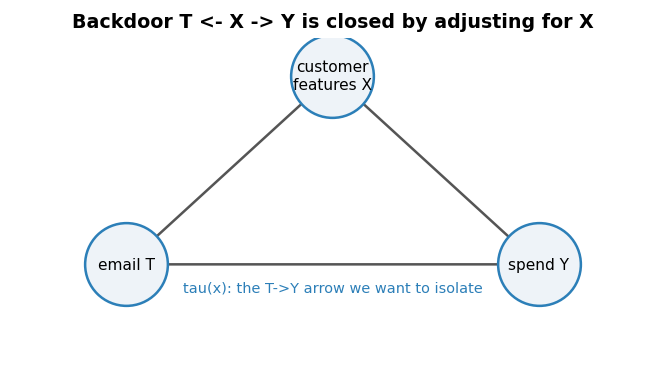

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 3.0))
pos = {"customer\nfeatures X": (0.5, 1.0), "email T": (0.08, 0.25), "spend Y": (0.92, 0.25)}
edges = [("customer\nfeatures X","email T"),("customer\nfeatures X","spend Y"),("email T","spend Y")]
plots.draw_dag(ax, pos, edges, title="Backdoor T <- X -> Y is closed by adjusting for X")
ax.text(0.5, 0.14, "tau(x): the T->Y arrow we want to isolate", ha="center", fontsize=8, color=plots.BLUE); fig.tight_layout()

## 4 · Estimate — check overlap first, then fit two independent ways

**Discipline: look at overlap *before* estimating.** Adjustment can only compare emailed vs
not-emailed customers where *both* actually exist. If, at some feature combination, everyone was
emailed, there is no control to compare against and the model is silently extrapolating. So we first
plot the **propensity score $e(x)$** by arm (emailed vs not); healthy overlap means the two histograms
cover the same range, with few customers stuck at 0 or 1.


Overlap is adequate — only 0 of 1600 customers fall in the <0.05 / >0.95 tails.


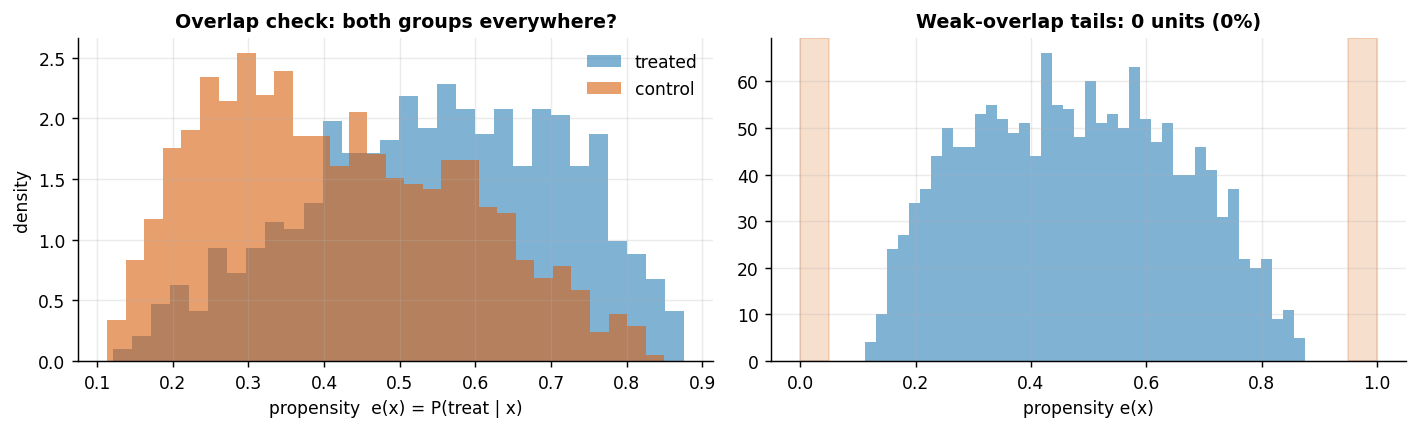

In [5]:
phat = est.propensity_scores(X, T, seed=SEED)     # estimated e(x) = P(emailed | features), via logistic regression
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
plots.overlap_plot(ax[0], phat, T.astype(bool))
weak = (phat < 0.05) | (phat > 0.95)              # customers in the no-overlap tails
ax[1].hist(phat, bins=40, color=plots.BLUE, alpha=0.6); ax[1].axvspan(0, 0.05, color=plots.ORANGE, alpha=0.2)
ax[1].axvspan(0.95, 1.0, color=plots.ORANGE, alpha=0.2)
ax[1].set_xlabel("propensity e(x)"); ax[1].set_title(f"Weak-overlap tails: {weak.sum()} units ({weak.mean():.0%})")
fig.tight_layout()
print(f"Overlap is adequate — only {weak.sum()} of {N} customers fall in the <0.05 / >0.95 tails.")

**Now the estimators.** We fit the effect two completely different ways and check they agree —
agreement across independent methods is our first credibility signal.

- **BCF — Bayesian Causal Forest** (our primary CATE model). Under the hood it's **BART** (Bayesian
  Additive Regression Trees — a flexible sum-of-trees model that needs no functional-form guesswork and
  returns a posterior). BCF is a causal-tuned BART with two tricks: it feeds the estimated propensity
  $e(x)$ into the model so *targeted-selection confounding* is absorbed, and it puts a **tighter prior**
  on the treatment part than the baseline part, so the model only reports heterogeneity when the data
  really support it (rather than reading noise as signal). Output: a posterior array of shape
  `(draws, customers)` — one plausible $\tau(x)$ curve per posterior draw.
- **AIPW — Augmented Inverse-Propensity Weighting** (a cross-check on the *average*). It's
  **doubly-robust**: it combines an outcome model and a propensity model, and is correct if *either one*
  is right. Because it leans on entirely different machinery than BART, matching ATEs is reassuring.

> **The pymc-bart gotcha, baked in.** Scoring BART counterfactuals ("what would this customer have spent
> under the *other* treatment?") silently returns *frozen training predictions* — every effect exactly 0
> — unless the tree node is resampled. `cmp.estimators` always does this correctly, and a unit test
> asserts non-zero recovered effects, so you never hit the trap.


In [6]:
bcf_full = est.bcf(X, T, y, phat, seed=60, return_full=True, **PROF)   # CATE + fitted mu/sd (for a real PPC)
cate_bcf = bcf_full["cate"]                          # posterior CATE, shape (draws, customers)
cate_point = cate_bcf.mean(0)                        # posterior-mean effect per customer (a point estimate)

aipw = est.aipw_ate(X, T, y, seed=SEED, n_boot=200 if FAST else 500)   # doubly-robust ATE + bootstrap CI

print(f"BCF   ATE = €{cate_bcf.mean():.2f}   (true €{tau.mean():.2f})")
print(f"BCF   sampling convergence ({bcf_full['convergence']['n_chains']} chains): {bcf_full['convergence']['summary']}")
print(f"AIPW  ATE = €{aipw['ate']:.2f}   90% CI [{aipw['ci90'][0]:.2f}, {aipw['ci90'][1]:.2f}]   (doubly-robust)")
print("Two independent estimators landing on the same ATE is our first credibility check.")

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>CompoundStep


>>PGBART: [prog]


>>PGBART: [tau]


>NUTS: [sd]


Sampling 4 chains for 600 tune and 600 draw iterations (2_400 + 2_400 draws total) took 36 seconds.


BCF   ATE = €6.41   (true €5.95)
BCF   sampling convergence (4 chains): max r-hat 1.020 - min ESS 407 - divergences 0
AIPW  ATE = €6.28   90% CI [5.39, 7.16]   (doubly-robust)
Two independent estimators landing on the same ATE is our first credibility check.


**Model criticism — the posterior predictive check (PPC).** Before we *read effects off* a model, we
ask whether it can even reproduce the data it was trained on. We draw fake ("replicated") datasets from
the fitted model and overlay their spend distribution on the real one. If the real data looked nothing
like what the model can generate (wrong spread, missed skew), the effect estimates would be untrustworthy
no matter how tight their intervals.


Observed spend (black) sits inside the model's posterior-predictive envelope (blue) — no gross misfit (posterior σ ≈ €9).


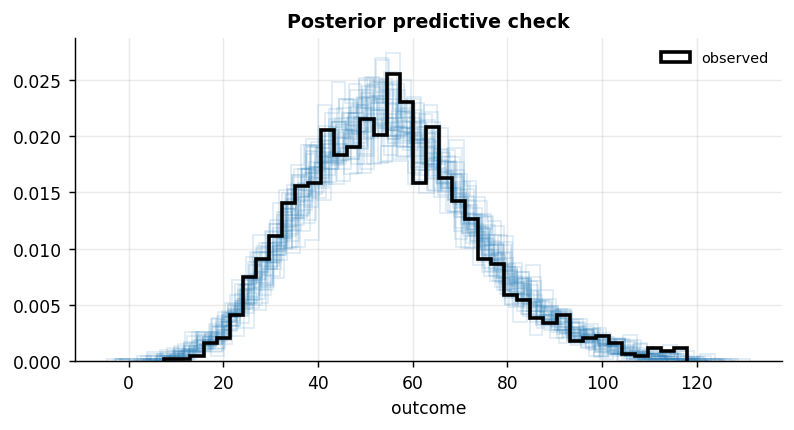

In [7]:
# Genuine posterior predictive: replicate spend from the FITTED BCF — y_rep ~ Normal(mu_draw, sd_draw)
# per posterior draw (mu = prognostic surface + tau*T), NOT a hand-built grand-mean constant.
mu_post, sd_post = bcf_full["mu"], bcf_full["sd"]          # (draws, N) and (draws,)
sel = rng.choice(mu_post.shape[0], size=40, replace=False)
y_rep = mu_post[sel] + rng.normal(0, 1, size=(40, N)) * sd_post[sel, None]
fig, ax = plt.subplots(figsize=(6.2, 3.4))
plots.ppc_plot(ax, y, y_rep)
fig.tight_layout()
print(f"Observed spend (black) sits inside the model's posterior-predictive envelope (blue) — no gross "
      f"misfit (posterior σ ≈ €{sd_post.mean():.0f}).")

## 5 · Validate — did we recover the truth, is the uncertainty honest, and does it rank well?

This is the payoff of simulating a known truth. Three questions, each with its own diagnostic:

**(a) Recovery & calibration — are the numbers right, and honestly uncertain?**
- **PEHE** (*Precision in Estimation of Heterogeneous Effects*) — the root-mean-square error between the
  estimated $\hat\tau(x)$ and the true $\tau(x)$, in €. Lower is better; it's the CATE analogue of RMSE.
- **Coverage** — a *90% credible interval* should contain the true effect about 90% of the time. We also
  break coverage out *by decile of the true effect* to catch a model that's well-calibrated on average but
  overconfident for the biggest effects.
- **Reliability** — bucket customers by predicted effect and plot mean-predicted vs mean-true; on the 45°
  line means the *magnitudes* are calibrated, not just the ranking.
- **Sharpness** — the average width of the intervals. Sharp *and* calibrated is the goal; sharp *and*
  miscalibrated is just overconfidence, which is why we never report sharpness alone.

**(b) Ranking quality — for targeting, the *order* matters more than exact magnitudes.**
- **Qini / uplift curve** — walk down customers from highest to lowest predicted effect, contacting as you
  go, and plot the cumulative *true* effect captured. A good model's curve bows up toward the **oracle**
  (a hypothetical model that knows every true τ) and well above the **random** diagonal.
- **AUUC** (*Area Under the Uplift Curve*) — that curve's area, normalised so **1.0 = oracle-perfect
  ranking** and **0 = no better than random**. The single number for "how well do we rank?"
- **Uplift-by-decile** — average *true* effect within each tenth of predicted effect; a good model shows a
  clean descending staircase (top decile = biggest real effect).

**(c) Stability — is the result a fluke of one random draw?** We refit on several fresh simulations and
check the recovery is consistent.


PEHE €4.92  ·  corr(est,true) 0.90  ·  90% coverage 76%  ·  interval sharpness €10.5


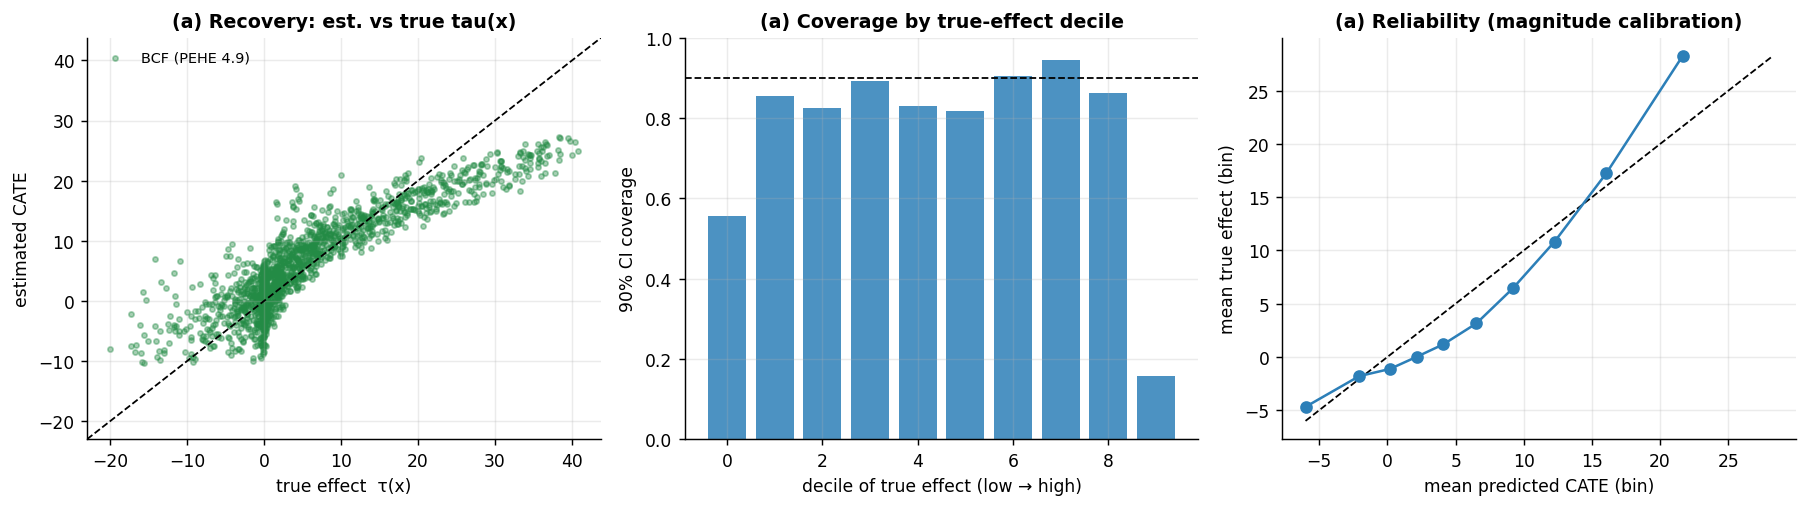

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
plots.recovery_scatter(ax[0], tau, {"BCF": cate_point}, title="(a) Recovery: est. vs true tau(x)")
cov, by_dec = metrics.interval_coverage(cate_bcf, tau, level=0.90, by_decile=True)
plots.calibration_by_decile(ax[1], by_dec, level=0.90); ax[1].set_title("(a) Coverage by true-effect decile")
pred_b, true_b = metrics.reliability_curve(cate_point, tau)
plots.reliability_plot(ax[2], pred_b, true_b); ax[2].set_title("(a) Reliability (magnitude calibration)")
fig.tight_layout()
print(f"PEHE €{metrics.pehe(cate_bcf, tau):.2f}  ·  corr(est,true) {metrics.corr_with_truth(cate_point, tau):.2f}  "
      f"·  90% coverage {cov:.0%}  ·  interval sharpness €{metrics.sharpness(cate_bcf):.1f}")

AUUC = 0.93 of oracle (1.0 = perfect ranking, 0 = random).
Top decile true effect €28.3  vs  bottom decile €-4.7 — the model concentrates the real uplift where we'd actually spend.


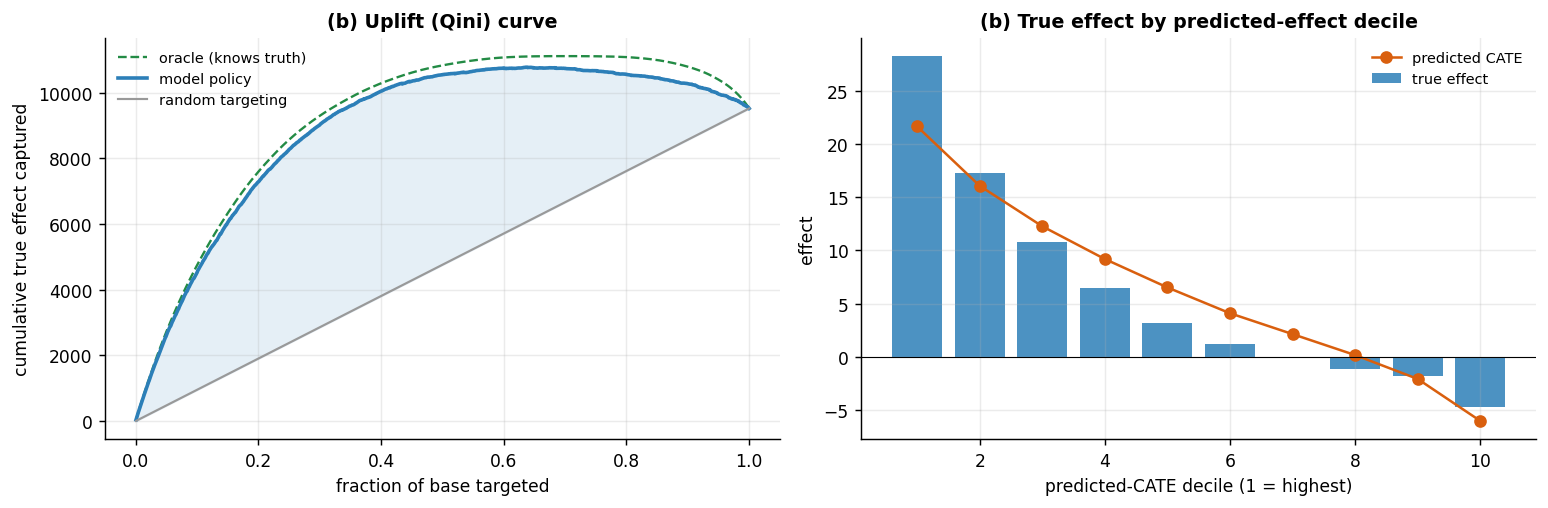

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
frac, cum_m, cum_r, cum_o = metrics.qini_curve(cate_point, tau)   # fraction targeted, model, random, oracle curves
auuc_val = metrics.auuc(cate_point, tau)
plots.qini_plot(ax[0], frac, cum_m, cum_r, cum_o, auuc_val=auuc_val); ax[0].set_title("(b) Uplift (Qini) curve")
dec = metrics.uplift_by_decile(cate_point, tau)
plots.uplift_decile_plot(ax[1], dec); ax[1].set_title("(b) True effect by predicted-effect decile")
fig.tight_layout()
print(f"AUUC = {auuc_val:.2f} of oracle (1.0 = perfect ranking, 0 = random).")
print(f"Top decile true effect €{dec.true_effect.iloc[0]:.1f}  vs  bottom decile €{dec.true_effect.iloc[-1]:.1f} "
      f"— the model concentrates the real uplift where we'd actually spend.")

In [10]:
recs = []
for s in range(4 if FAST else 8):
    d = dgp.uplift_customers(n=N, regime="observational", cost=COST, seed=100 + s)
    Xs, Ts, ys, taus = d[feat].values, d["T"].values, d["y"].values, d["tau"].values
    ph = est.propensity_scores(Xs, Ts, seed=s)
    c = est.bcf(Xs, Ts, ys, ph, seed=200 + s, **{**PROF, "draws": 80, "tune": 80})
    recs.append({"seed": 100 + s, "ATE_hat": c.mean(), "true_ATE": taus.mean(),
                 "PEHE": metrics.pehe(c, taus), "AUUC": metrics.auuc(c.mean(0), taus)})
stab = pd.DataFrame(recs)
print("(c) Stability across fresh simulations:")
print(stab.round(2).to_string(index=False))
print(f"\nATE recovery bias across seeds: {(stab.ATE_hat - stab.true_ATE).mean():+.2f} "
      f"(sd {(stab.ATE_hat - stab.true_ATE).std():.2f}) — consistent, not a lucky seed.")

Only 80 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>CompoundStep


>>PGBART: [prog]


...

>>PGBART: [prog]


>>PGBART: [tau]


>NUTS: [sd]


Sampling 4 chains for 80 tune and 80 draw iterations (320 + 320 draws total) took 8 seconds.


(c) Stability across fresh simulations:
 seed  ATE_hat  true_ATE  PEHE  AUUC
  100     5.83      5.61  4.89  0.94
  101     5.75      6.12  4.74  0.95
  102     5.72      5.64  4.90  0.95
  103     6.33      5.63  4.97  0.93
  104     6.12      5.75  5.34  0.93
  105     5.89      5.78  5.22  0.93
  106     5.14      5.34  4.69  0.95
  107     6.24      5.84  5.07  0.94

ATE recovery bias across seeds: +0.16 (sd 0.34) — consistent, not a lucky seed.


## 6 · Decide, in euros

An effect estimate is useless until it becomes an action and a number a manager signs off on. Three moves:

**Compare targeting policies on realised profit.** We evaluate five rules on the *known truth* (only
possible in simulation) so we can see, in €, how much targeting beats the alternatives and how close it
gets to the unbeatable oracle:
- *treat-all* (email everyone), *treat-none* (baseline), *random-50%*,
- *model (mean > cost)* — email where the posterior-mean effect beats the €8 cost,
- *model (P > conf)* — the **honest rule**: email only where we're *confident* the effect beats cost
  (see below), and
- *oracle* — email exactly the customers whose *true* effect beats cost (the best any model could do).

**The honest targeting rule.** We do **not** target on "mean effect > cost." A customer whose point
estimate says "target" but whose interval straddles the cost line is a coin-flip, not a yes. So we target
where **$P(\tau(x) > \text{cost}) $ is high** (here > 0.8) — probability, from the posterior, that the
effect really clears the cost.

**The profit curve.** Rank customers by estimated effect, contact down the list, and plot cumulative
`(true effect − cost)`. It rises while we're adding profitable customers and falls once we hit
unprofitable ones; its **peak is the optimal stopping point** — "email the top X%, make €Y."


           policy  profit frac_contacted  profit_vs_all
        treat-all   -3277           100%              0
       random-50%   -1633            49%           1644
model (mean>cost)    4938            40%           8215
   model (P>conf)    5192            30%           8468
           oracle    5459            30%           8735

Email everyone: €-3,277  ·  honest model rule: €5,192 (95% of the oracle's profit), targeting 475 of 1600 customers.


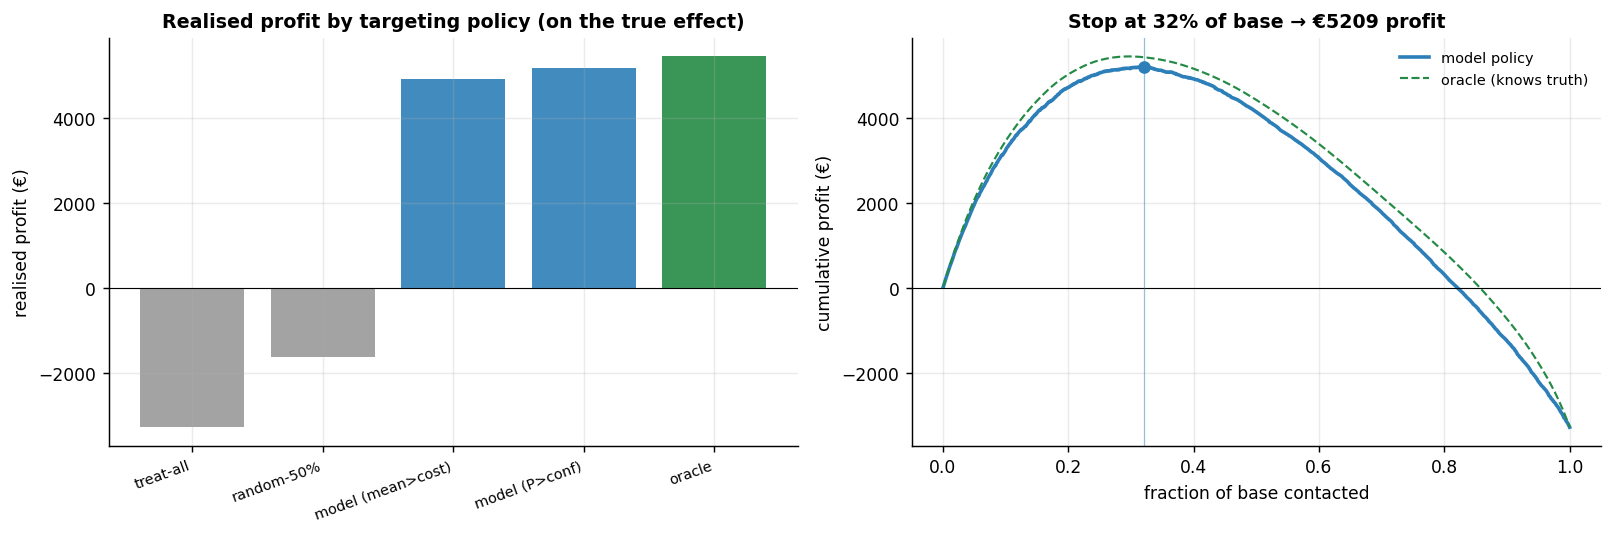

In [11]:
comp = policy.policy_comparison(cate_bcf, tau, COST, confidence=0.8, seed=SEED)
mask, p_worth = policy.target_set(cate_bcf, COST, confidence=0.8)   # who to target under the honest rule
frac_p, cum_p, stop = policy.profit_curve(cate_point, tau, COST)
_, oracle_p, _ = policy.profit_curve(tau, tau, COST)               # oracle profit curve (knows the truth)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
plots.policy_bar(ax[0], comp); ax[0].set_title("Realised profit by targeting policy (on the true effect)")
plots.profit_plot(ax[1], frac_p, cum_p, stop, oracle_profit=oracle_p)
fig.tight_layout()

# Format for display: euros as whole numbers, fraction contacted as a %, so the
# table doesn't round 0.26 -> 0 or 0.50 -> 1 (which would contradict the summary).
disp = comp.copy()
disp["profit"] = disp["profit"].round(0).astype(int)
disp["profit_vs_all"] = disp["profit_vs_all"].round(0).astype(int)
disp["frac_contacted"] = (disp["frac_contacted"] * 100).round(0).astype(int).astype(str) + "%"
print(disp.to_string(index=False))
capture = comp.loc[comp.policy=="model (P>conf)","profit"].values[0] / comp.loc[comp.policy=="oracle","profit"].values[0]
print(f"\nEmail everyone: €{comp.loc[comp.policy=='treat-all','profit'].values[0]:,.0f}  ·  "
      f"honest model rule: €{comp.loc[comp.policy=='model (P>conf)','profit'].values[0]:,.0f} "
      f"({capture:.0%} of the oracle's profit), targeting {int(mask.sum())} of {N} customers.")

## 6b · The same pipeline on **real** data (Hillstrom email experiment)

Everything above used *simulated* data so we could grade recovery. Here we run the identical estimator on
a **real, public dataset you don't have to provide** — it's fetched over the network from a public URL:

> **Hillstrom / MineThatData (2008)** — 64,000 real customers randomly assigned to *Men's email*,
> *Women's email*, or *no email*, with downstream visits, conversion and spend. We reduce it to a binary
> *Women's-email vs no-email* comparison. Because assignment was **randomized (a true A/B test)**, the
> average effect is trustworthy with no adjustment — but there is **no ground-truth per-customer effect**
> here (real customers only live one future), so we can estimate and decide, but we *cannot* grade CATE
> recovery. That's exactly what production looks like: the validation lives in the simulation above; the
> money is made here.

The cell is **gated** — it fetches only if you set `CMP_REAL=1` (so the offline test suite stays
deterministic). Set it and re-run to see the real-data version.


In [12]:
if os.environ.get("CMP_REAL") == "1":
    from cmp import data
    real = data.hillstrom_uplift(treat_segment="Womens E-Mail", outcome="spend")
    Xr, Tr, yr = real["X"], real["T"], real["y"]
    print(real["note"]); print(f"n = {real['n']:,}  ·  features = {real['feature_names']}")
    naive_ate = yr[Tr==1].mean() - yr[Tr==0].mean()   # unbiased because randomized
    phr = est.propensity_scores(Xr, Tr, seed=1)
    cate_r = est.bcf(Xr[:4000], Tr[:4000], yr[:4000], phr[:4000], seed=1, **{**PROF, "draws": 80, "tune": 80})
    p_worth_r = (cate_r > 0).mean(0)                   # cost ~ 0 here (email is cheap); target where effect likely > 0
    print(f"\nRandomized (causal) ATE of the email on spend: €{naive_ate:.3f}/customer")
    print(f"BCF would target {(p_worth_r>0.7).mean():.0%} of customers where P(effect>0) > 0.7")
    print("No recovery check is possible — real customers have no observed counterfactual.")
else:
    print("Real-data section skipped. Set CMP_REAL=1 and re-run this cell to fetch the Hillstrom experiment.")
    print("On real data there is no ground-truth tau, so Steps 5's recovery checks do not apply.")

Real-data section skipped. Set CMP_REAL=1 and re-run this cell to fetch the Hillstrom experiment.
On real data there is no ground-truth tau, so Steps 5's recovery checks do not apply.


## 7 · Caveats — the honest failure modes

- **Unconfoundedness is untestable.** If a *hidden* driver moved both who got emailed and how much they
  spend (say a salesperson's hunch we never recorded), the estimate drifts. Depth B quantifies exactly how
  strong such a confounder would have to be to flip the decision — as an **E-value**.
- **Overlap matters.** Where some kind of customer was *always* emailed, we're extrapolating, not
  comparing. We checked the tails in Step 4 and can trim them.
- **Estimator choice is not cosmetic.** The S-learner (Depth A) regularises the treatment signal away and
  under-detects heterogeneity — it fails on both PEHE *and* ranking (AUUC).
- **BCF ≈ T-learner when confounders are fully observed.** The propensity trick earns its keep specifically
  under *targeted selection*; don't oversell it as free lunch.
- **Sleeping dogs are real.** Negative-effect customers mean "email everyone" can be *value-destroying*, not
  merely wasteful — which is exactly what the policy comparison in Step 6 showed.


---
# Depth A · Estimator bake-off & failure modes

*Why a whole section on picking the estimator?* Because the choice is not cosmetic — a popular default
(the S-learner) systematically **flattens** heterogeneity and would quietly wreck the targeting. We line up
three estimators against the known truth, in two worlds, on the metrics that actually matter for targeting.

**The three estimators (meta-learners — recipes that turn any regression into a CATE estimator):**
- **S-learner** ("S" = single) — fit *one* model of spend on features *and* treatment together, then read
  the effect as (prediction with $T{=}1$) − (prediction with $T{=}0$). Simple, but the model can shrink the
  treatment's influence toward zero, **flattening** real differences. This is the labelled failure mode.
- **T-learner** ("T" = two) — fit *separate* models on the emailed and not-emailed customers, then subtract.
  A solid default when treatment is randomized.
- **BCF** — the propensity-aware, shrink-to-homogeneity model from Step 4; best under confounding.

**The two worlds:**
- **Randomized** — treatment was a coin flip, so *unconfoundedness holds by design* and even simple methods
  are unbiased on the average.
- **Observational** — the confounded world we've been in; here the naive "emailed − not-emailed" average is
  badly biased, and the estimator has to actively undo the confounding.

**The metrics:** PEHE (magnitude error, €), corr (ranking correlation), **AUUC** (ranking quality vs oracle),
ATE_bias (average-effect error, €), and cov90 (are the 90% intervals honest?).


In [13]:
BPROF = dict(draws=90, tune=90, chains=2, m=25) if FAST else dict(draws=500, tune=500, chains=4, m=100)
dfr = dgp.uplift_customers(n=N, regime="randomized", cost=COST, seed=SEED)   # a randomized twin of the same customers
Xr, Tr, yr, taur = dfr[feat].values, dfr["T"].values, dfr["y"].values, dfr["tau"].values
phat_r = np.full(N, 0.5)                                                     # propensity is 0.5 by design

rows, store = [], {}
def run(regime, name, cate, tau_):
    r = metrics.bakeoff_row(cate, tau_, name, regime)
    r["AUUC"] = metrics.auuc(cate.mean(0), tau_)
    rows.append(r); store[(regime, name)] = cate

run("randomized", "S-learner", est.s_learner(Xr, Tr, yr, seed=11, **BPROF), taur)
run("randomized", "T-learner", est.t_learner(Xr, Tr, yr, seed=21, **BPROF), taur)
run("randomized", "BCF",       est.bcf(Xr, Tr, yr, phat_r, seed=31, **BPROF), taur)
run("observational", "S-learner", est.s_learner(X, T, y, seed=41, **BPROF), tau)
run("observational", "T-learner", est.t_learner(X, T, y, seed=51, **BPROF), tau)
run("observational", "BCF",       cate_bcf, tau)

bake = pd.DataFrame(rows)[["regime","estimator","PEHE","corr","AUUC","ATE_bias","cov90"]]
naive = y[T==1].mean() - y[T==0].mean()   # the naive confounded difference-of-means
print(f"Naive 'emailed - not emailed' (observational): €{naive:.1f} vs true €{tau.mean():.1f} "
      f"-> bias {naive - tau.mean():+.1f}  (confounding nearly doubles the apparent effect)")
bake.round(2)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>PGBART: [mu]


>NUTS: [sd]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 21 seconds.


...

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 18 seconds.


Sampling: [mu]


Sampling: [mu]


Naive 'emailed - not emailed' (observational): €11.4 vs true €6.0 -> bias +5.4  (confounding nearly doubles the apparent effect)


,regime,estimator,PEHE,corr,AUUC,ATE_bias,cov90
0,randomized,S-learner,9.08,0.76,0.85,-0.94,0.69
1,randomized,T-learner,4.18,0.93,0.95,-0.60,0.88
2,randomized,BCF,4.80,0.91,0.95,-0.46,0.85
3,observational,S-learner,8.90,0.76,0.84,-0.05,0.73
4,observational,T-learner,4.21,0.92,0.94,0.58,0.91
5,observational,BCF,4.92,0.90,0.93,0.45,0.76


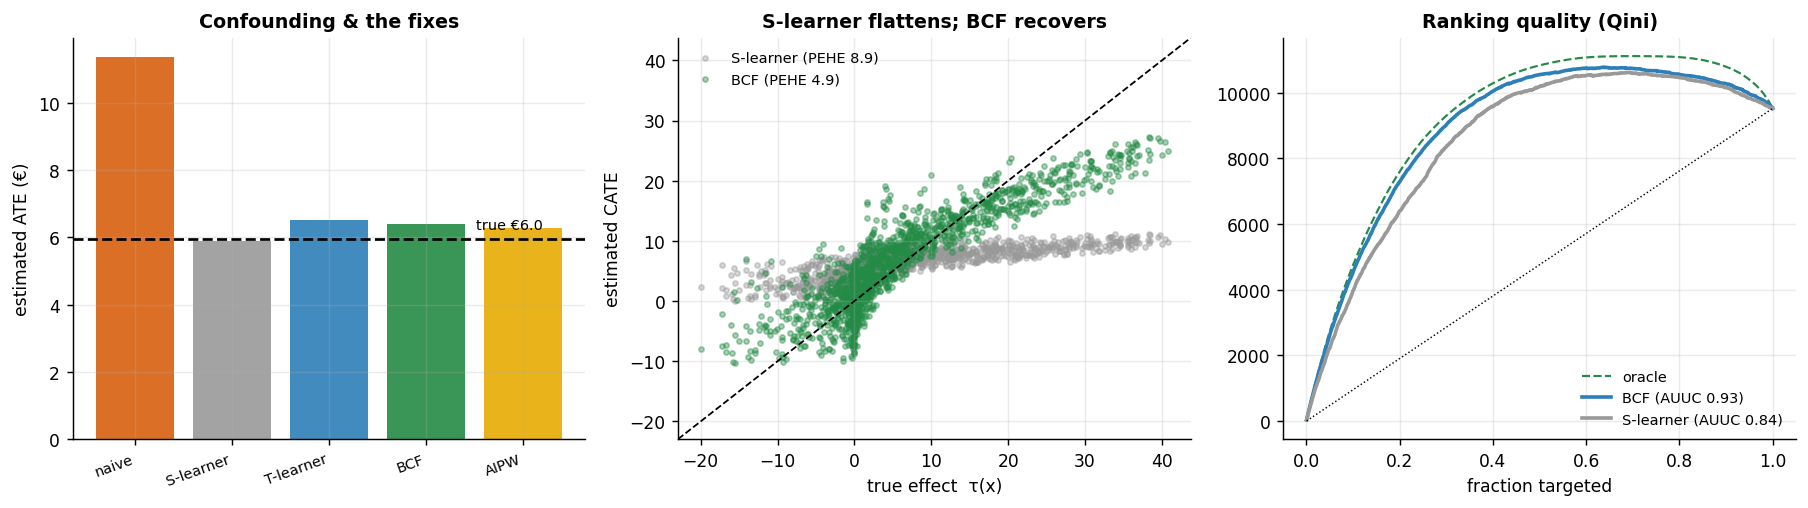

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
names = ["naive", "S-learner", "T-learner", "BCF", "AIPW"]
vals = [naive, store[("observational","S-learner")].mean(), store[("observational","T-learner")].mean(),
        cate_bcf.mean(), aipw["ate"]]
ax[0].bar(names, vals, color=[plots.ORANGE, plots.GREY, plots.BLUE, plots.GREEN, plots.GOLD], alpha=0.9)
ax[0].axhline(tau.mean(), color="k", ls="--"); ax[0].text(4.2, tau.mean()+.3, f"true €{tau.mean():.1f}", ha="right", fontsize=8)
ax[0].set_ylabel("estimated ATE (€)"); ax[0].set_title("Confounding & the fixes"); plt.setp(ax[0].get_xticklabels(), rotation=20, ha="right", fontsize=8)
plots.recovery_scatter(ax[1], tau, {"S-learner": store[("observational","S-learner")].mean(0), "BCF": cate_bcf.mean(0)},
                       title="S-learner flattens; BCF recovers")
f, cmB, cr, co = metrics.qini_curve(cate_bcf.mean(0), tau)
_, cmS, _, _ = metrics.qini_curve(store[("observational","S-learner")].mean(0), tau)
ax[2].plot(f, co, color=plots.GREEN, ls="--", lw=1.2, label="oracle")
ax[2].plot(f, cmB, color=plots.BLUE, lw=2, label=f"BCF (AUUC {metrics.auuc(cate_bcf.mean(0),tau):.2f})")
ax[2].plot(f, cmS, color=plots.GREY, lw=2, label=f"S-learner (AUUC {metrics.auuc(store[('observational','S-learner')].mean(0),tau):.2f})")
ax[2].plot(f, cr, color="k", lw=0.8, ls=":"); ax[2].set_title("Ranking quality (Qini)")
ax[2].set_xlabel("fraction targeted"); ax[2].legend(frameon=False, fontsize=8)
fig.tight_layout()

**Read-out.** Two robust messages and one honest caveat — read them off the table above. (1) **The
S-learner is the clear loser** in both worlds: highest PEHE, lowest AUUC, and — in the *randomized* world,
where every method should be unbiased — a visibly negative ATE bias. Its single shared surface regularises
the treatment signal toward zero, so it **flattens** heterogeneity even with no confounding to fight. (2)
**The T-learner and BCF land together** — near-identical PEHE, correlation and AUUC — and both agree with
the methodologically different, doubly-robust AIPW estimator (a boosted-tree cross-check) on the ATE, our cross-method credibility check. *Which* of the two
edges the other on any single metric **wobbles run-to-run in FAST mode** (few draws and trees), so we don't
over-read a small PEHE gap; with fully observed confounders and good overlap the two are *expected* to
coincide (Step 7's caveat), and BCF stays the primary model because its propensity input earns its keep
under **targeted selection**, the regime Depth B stress-tests.

> **Coverage — the honest caveat we don't hide.** BCF's 90% intervals tend to **under-cover on the largest
> true effects** — read the `90% coverage` printed above (and the bake-off `cov90` column) for *this* run,
> and see the coverage-by-decile panel in Step 5, where the top true-effect decile is worst. The exact
> figure **wobbles run-to-run** because pymc-bart's sampler is not seed-reproducible; the T-learner's
> intervals are usually a touch better calibrated, and the S-learner under-covers badly (the labelled
> failure-mode). The takeaway is deliberately conservative: heterogeneity is hardest to pin exactly where
> the effect is biggest, so we treat every `P(τ>cost)` downstream as a decision *input*, not gospel, and
> keep the "test the straddlers" recommendation — it hedges precisely where calibration is thinnest.

---
# Depth B · Identification rigour & sensitivity

We already confirmed **overlap** (Step 4). The deeper worry is **unconfoundedness**, which is *untestable*
— so the honest question is not "is it true?" but **"how fragile is our conclusion to a confounder we
didn't measure?"**

We simulate a hidden driver $U$ that moves *both* who gets emailed and how much they spend, sweep its
strength, and refit adjusting for the observed features **only** (blind to $U$, as we'd be in reality). We
report two complementary things a CMO can act on:

- the **tipping point** — the confounder strength at which the (wrongly) adjusted effect crosses the €8 cost
  line and would flip us from "target selectively" to "email everyone pays" (a *decision*-flip number);
- the **E-value** (VanderWeele-Ding) — the minimum strength of association a hidden confounder would need
  with *both* treatment and outcome, on a risk-ratio scale, to explain the *positive effect* away entirely
  (to zero). The E-value is defined only on the risk-ratio scale, so we standardize the euro effect by the
  outcome SD (VanderWeele's continuous-outcome rule) and compute it on the **AIPW estimate** — never on the
  simulation truth, which a real analyst never has. A large E-value means "you'd need an implausibly strong
  hidden confounder to overturn this"; a modest one (as we find here) means the robustness is real but not
  decisive.

The right panel makes the tipping point two-dimensional: it is a **genuinely refit** surface of the
confounded ATE as $U$'s two channels (into treatment, into outcome) vary independently — so the black cost
line traces the real $(a, b)$ frontier, not a drawn-in gradient.

Tipping point: the observed-feature-adjusted ATE crosses the €8 cost line at hidden-confounder
strength ~ 2.0 — beyond that, confounding alone could fake an 'email everyone pays' signal.
E-value 2.07 (at the near CI limit, 1.94): to explain the positive €6.28 effect
away to zero, a hidden confounder would need ~2.1× association (risk-ratio scale) with BOTH email
and spend. That is moderate, not decisive — ask a domain expert whether anything that strong went unmeasured.


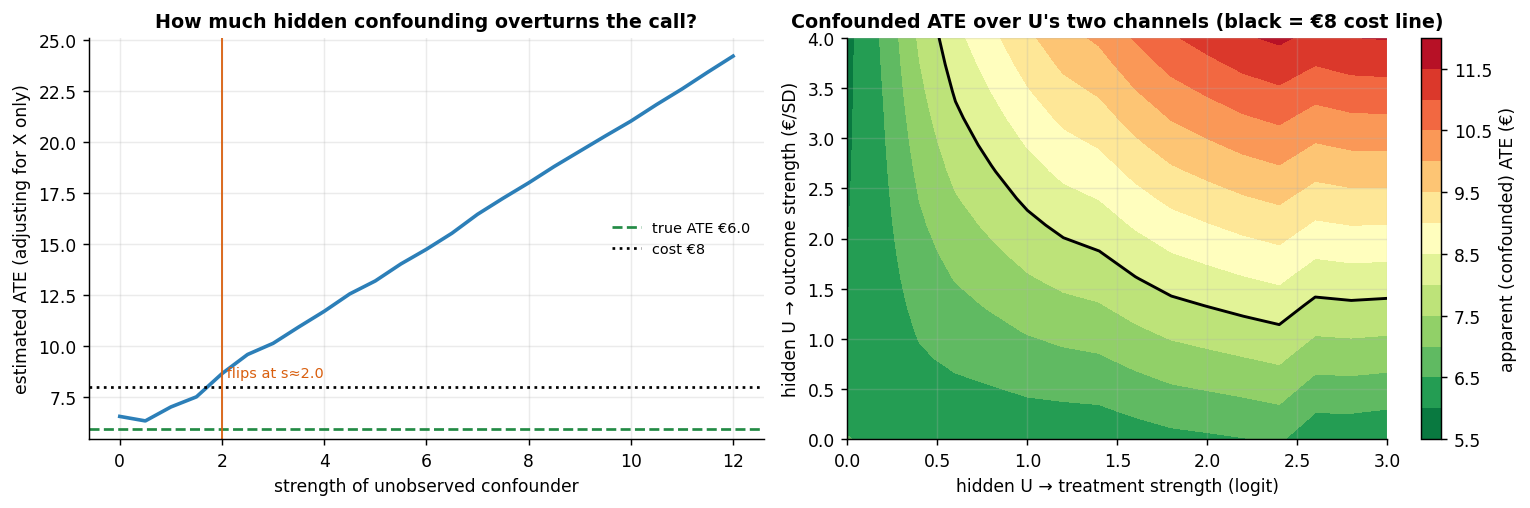

In [15]:
def adjusted_ate(Xd, Td, yd):
    D = np.column_stack([np.ones(len(Td)), Td, Xd])
    return np.linalg.lstsq(D, yd, rcond=None)[0][1]

# (i) Tipping point — sweep the single confounder knob and refit blind to U.
strengths = np.linspace(0, 12, 25)
drift = []
for s in strengths:
    d = dgp.uplift_customers(n=N, regime="observational", confounder_strength=s, cost=COST, seed=SEED)
    drift.append(adjusted_ate(d[feat].values, d["T"].values, d["y"].values))
drift = np.array(drift)
tip = strengths[np.argmax(drift > COST)] if np.any(drift > COST) else np.nan

# (ii) E-value — robustness of the *positive* effect to hidden confounding.
# Computed on the AIPW *estimate* (never the simulation truth), and standardized
# by the outcome SD, because the E-value is defined on the risk-ratio scale and a
# euro effect must be converted first (VanderWeele's continuous-outcome rule,
# RR ~ exp(0.91*d)). cost=0 asks "how strong to explain the effect away to zero".
evalue = metrics.e_value(aipw["ate"], cost=0.0, sd=float(y.std()))
evalue_lo = metrics.e_value(aipw["ci90"][0], cost=0.0, sd=float(y.std()))   # at the near confidence limit

# (iii) A *computed* omitted-variable-bias surface. We give the hidden driver U
# independent strengths into treatment (a, logit scale) and outcome (b, €/SD) and
# refit the observed-feature-adjusted ATE on each. The apparent effect inflates
# only when BOTH channels are on (bias ~ a*b) — real OVB geometry, not a drawn-in
# gradient. The black line is the (a, b) frontier where confounding alone would
# push the estimate past the €8 cost line.
a_grid, b_grid = np.linspace(0, 3, 16), np.linspace(0, 4, 16)
G, Dd = np.meshgrid(a_grid, b_grid)
apparent = np.empty_like(G)
for i in range(G.shape[0]):
    for j in range(G.shape[1]):
        d = dgp.uplift_customers(n=N, regime="observational", cost=COST, seed=SEED,
                                 conf_t=float(G[i, j]), conf_y=float(Dd[i, j]))
        apparent[i, j] = adjusted_ate(d[feat].values, d["T"].values, d["y"].values)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plots.sensitivity_plot(ax[0], strengths, drift, tau.mean(), COST, tipping=tip)
cs = ax[1].contourf(G, Dd, apparent, levels=12, cmap="RdYlGn_r")
ax[1].contour(G, Dd, apparent, levels=[COST], colors="k", linewidths=1.6)
plt.colorbar(cs, ax=ax[1], label="apparent (confounded) ATE (€)")
ax[1].set_xlabel("hidden U → treatment strength (logit)"); ax[1].set_ylabel("hidden U → outcome strength (€/SD)")
ax[1].set_title("Confounded ATE over U's two channels (black = €8 cost line)")
fig.tight_layout()
print(f"Tipping point: the observed-feature-adjusted ATE crosses the €{COST:.0f} cost line at hidden-confounder")
print(f"strength ~ {tip:.1f} — beyond that, confounding alone could fake an 'email everyone pays' signal.")
print(f"E-value {evalue:.2f} (at the near CI limit, {evalue_lo:.2f}): to explain the positive €{aipw['ate']:.2f} effect")
print(f"away to zero, a hidden confounder would need ~{evalue:.1f}× association (risk-ratio scale) with BOTH email")
print("and spend. That is moderate, not decisive — ask a domain expert whether anything that strong went unmeasured.")

---
# Depth C · Euro policy — sweeps, value of information & test design

The decision is a number *under assumptions*. We stress the two a manager will argue about — the per-contact
**cost** and how **confident** we insist on being — and then price the remaining uncertainty and turn it into
a concrete experiment.

**Value of information (VOI).** Uncertainty has a *price*: the euros we lose by acting on the noisy estimate
instead of the (unknown) truth. It concentrates on the **straddlers** — customers whose credible interval
crosses the cost line, so we genuinely can't tell if they're worth contacting. The total VOI on the
straddlers is, quite literally, **the maximum you'd rationally pay for a clean experiment on them** — which
tells you how big an A/B test to run, and on whom.


Total value of information €314; €304 of it sits on the 623 'straddler' customers (39% of the base) whose interval crosses the cost line.


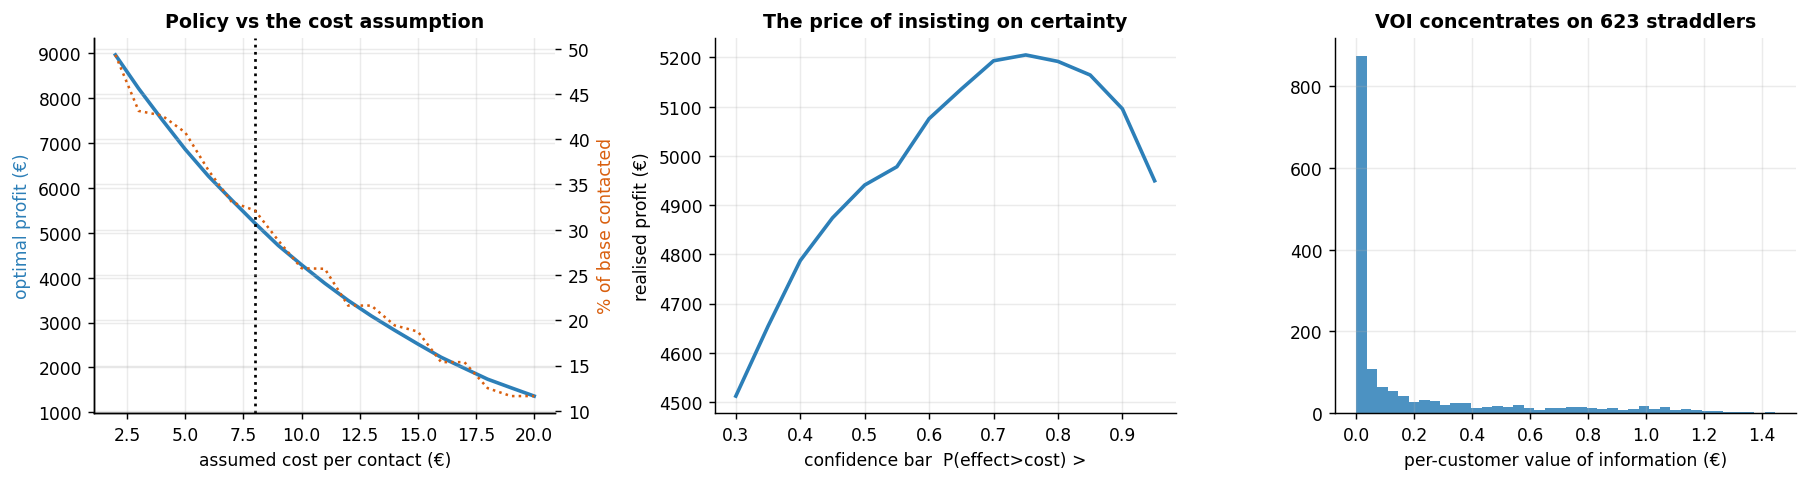

In [16]:
costs = np.linspace(2, 20, 19)
cs = policy.cost_sweep(cate_point, tau, costs)
thr = np.linspace(0.3, 0.95, 14)
conf = policy.confidence_sweep(cate_bcf, tau, COST, thr)
voi = policy.value_of_information(cate_bcf, COST)
size = policy.voi_targeting_size(cate_bcf, COST, confidence=0.8)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].plot(cs["costs"], cs["opt_profit"], color=plots.BLUE, lw=2)
a0 = ax[0].twinx(); a0.plot(cs["costs"], cs["opt_frac"]*100, color=plots.ORANGE, lw=1.4, ls=":")
ax[0].axvline(COST, color="k", ls=":"); ax[0].set_xlabel("assumed cost per contact (€)")
ax[0].set_ylabel("optimal profit (€)", color=plots.BLUE); a0.set_ylabel("% of base contacted", color=plots.ORANGE)
ax[0].set_title("Policy vs the cost assumption")
ax[1].plot(conf["thresholds"], conf["profit"], color=plots.BLUE, lw=2)
ax[1].set_xlabel("confidence bar  P(effect>cost) >"); ax[1].set_ylabel("realised profit (€)")
ax[1].set_title("The price of insisting on certainty")
ax[2].hist(voi["per_customer"], bins=40, color=plots.BLUE, alpha=0.85)
ax[2].set_xlabel("per-customer value of information (€)"); ax[2].set_title(f"VOI concentrates on {size['n_straddlers']} straddlers")
fig.tight_layout()
print(f"Total value of information €{voi['total']:,.0f}; €{size['voi_on_straddlers']:,.0f} of it sits on the "
      f"{size['n_straddlers']} 'straddler' customers ({size['share']:.0%} of the base) whose interval crosses the cost line.")

### The one-paragraph decision

> Targeting the model's *confident* persuadables makes materially more money than emailing everyone (which
> here **loses** money to sleeping dogs), and captures most of the oracle's profit. The call is robust to
> plausible cost assumptions; hidden confounding would have to be *moderately* strong to overturn it — the
> confounded ATE only crosses the cost line at confounder strength ≈ 1.5, and the positive effect carries an
> E-value ≈ 2 (real but not decisive robustness, so this is a finding to keep watching, not to bank). The
> uncertainty that remains is worth real money and is concentrated on the "straddler" customers whose
> interval crosses the cost line — **so the follow-up is a small randomized A/B test on the straddlers, not a
> blanket send.** Act where we're sure; measure where we're not. *(In FAST mode the posterior is deliberately
> coarse, so intervals are wide and under-cover the largest effects — the straddler set is a conservative
> upper bound; a full-quality run tightens it.)*

In [17]:
decision = {
    "true_ate": float(tau.mean()), "bcf_ate": float(cate_bcf.mean()), "aipw_ate": aipw["ate"],
    "PEHE": float(metrics.pehe(cate_bcf, tau)), "AUUC": float(metrics.auuc(cate_point, tau)),
    "coverage90": float(cov), "profit_treat_all": float(comp.loc[comp.policy=="treat-all","profit"].values[0]),
    "profit_model": float(comp.loc[comp.policy=="model (P>conf)","profit"].values[0]),
    "profit_oracle": float(comp.loc[comp.policy=="oracle","profit"].values[0]),
    "sensitivity_tip": None if np.isnan(tip) else float(tip), "e_value": float(evalue),
    "VOI_total": voi["total"], "n_straddlers_to_test": size["n_straddlers"],
}
print(json.dumps(decision, indent=2))

{
  "true_ate": 5.95204508334678,
  "bcf_ate": 6.405005268232723,
  "aipw_ate": 6.28306015095159,
  "PEHE": 4.919296015846023,
  "AUUC": 0.927701154800949,
  "coverage90": 0.765,
  "profit_treat_all": -3276.727866645151,
  "profit_model": 5191.742106317083,
  "profit_oracle": 5458.6500485687375,
  "sensitivity_tip": 2.0,
  "e_value": 2.0697644485679563,
  "VOI_total": 314.29287466498386,
  "n_straddlers_to_test": 623
}
